# ML Fundamentals: Classification Benchmark on Astronomical Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. DATA LOADING & PREPROCESSING

In [2]:
print("--- Memuat Data ---")
# Sesuaikan path ini dengan lokasi file CSV
df = pd.read_csv('/content/star_classification.csv')

# Drop kolom identifier yang tidak relevan untuk ML
cols_to_drop = ['obj_ID', 'run_ID', 'rerun_ID', 'field_ID', 'spec_obj_ID', 'fiber_ID']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['class'])
y = df['class']

# Label Encoding untuk kolom target (GALAXY: 0, QSO: 1, STAR: 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Splitting dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Standarisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

--- Memuat Data ---


## 2. INISIALISASI MODEL

In [3]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

## 3. TRAINING & EVALUASI

In [4]:
results = {}
conf_matrices = {}

print("\n--- Hasil Evaluasi Model ---")
for name, model in models.items():
    # Training Model
    model.fit(X_train_scaled, y_train)
    # Prediksi
    y_pred = model.predict(X_test_scaled)
    # Evaluasi Akurasi
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    print(f"\n[{name}]")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))


--- Hasil Evaluasi Model ---

[Decision Tree]
Accuracy: 0.9661
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     11860
         QSO       0.91      0.92      0.92      3797
        STAR       1.00      0.99      1.00      4343

    accuracy                           0.97     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000


[Random Forest]
Accuracy: 0.9795
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11860
         QSO       0.97      0.93      0.95      3797
        STAR       1.00      1.00      1.00      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000


[Logistic Regression]
Accuracy: 0.9545
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96  

## 4. VISUALISASI

In [5]:
sns.set_style("whitegrid")

### Visualisasi 1: Distribusi Kelas

/tmp/ipykernel_5957/1756689911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


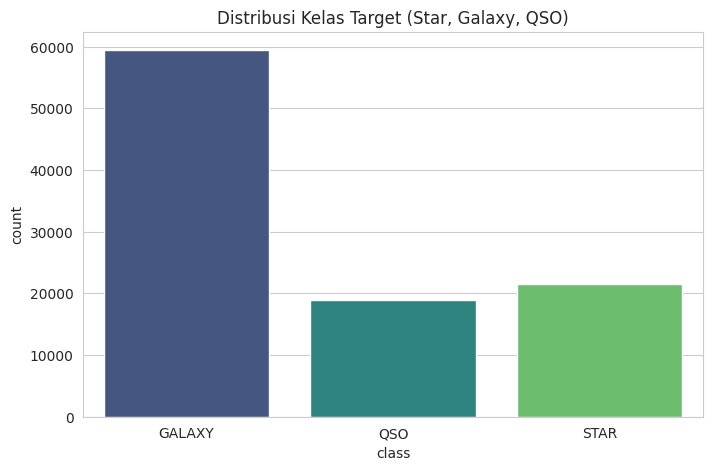

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Distribusi Kelas Target (Star, Galaxy, QSO)')
plt.show()

### Visualisasi 2: Perbandingan Akurasi Model

/tmp/ipykernel_5957/361793011.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')


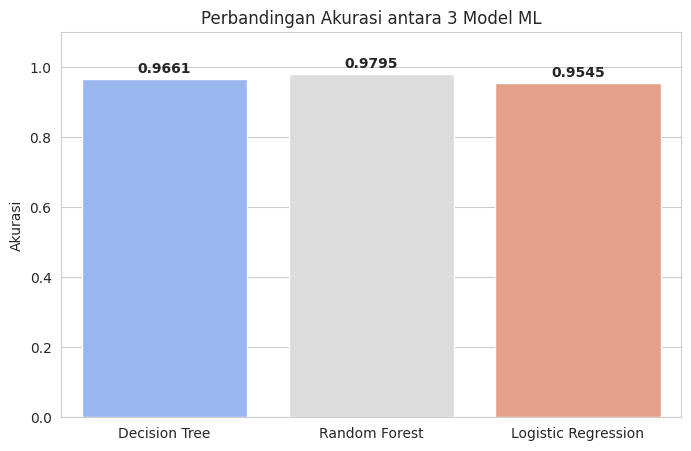

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.title('Perbandingan Akurasi antara 3 Model ML')
plt.ylabel('Akurasi')
plt.ylim(0, 1.1)
# Menambahkan label angka di atas bar
for i, v in enumerate(results.values()):
    ax.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')
plt.show()

### Visualisasi 3: Confusion Matrices

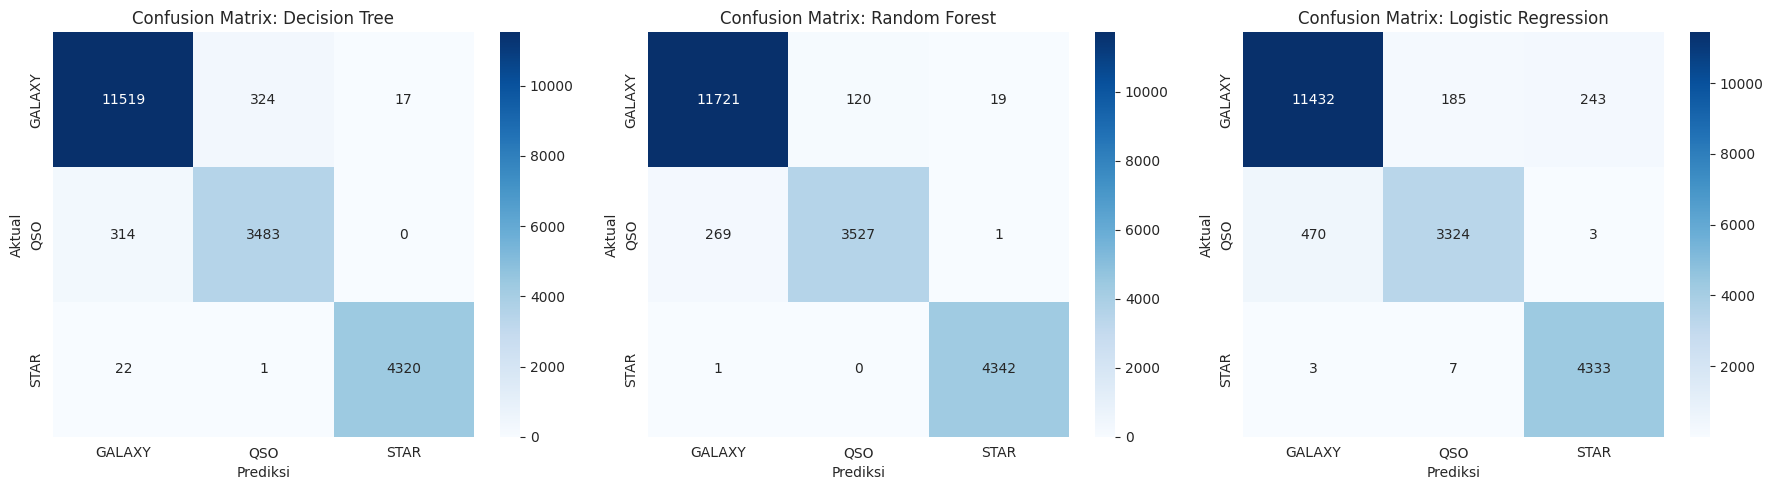

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')
plt.tight_layout()
plt.show()

### Visualisasi 4: Feature Importance (Berdasarkan Random Forest)

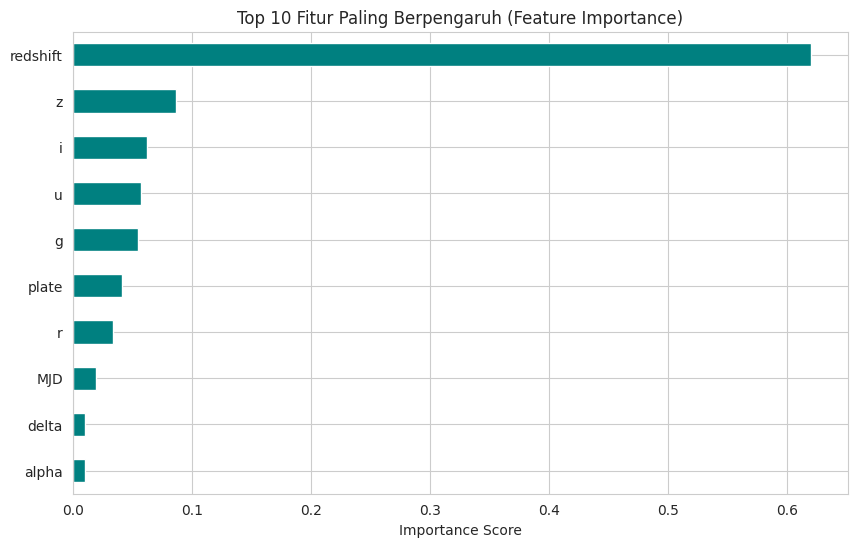

In [9]:
rf_model = models['Random Forest']
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Fitur Paling Berpengaruh (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

## Eksplorasi Lanjutan

In [10]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

### ADVANCED 1: HYPERPARAMETER TUNING (Decision Tree)

In [11]:
print("--- 1. Hyperparameter Tuning (Decision Tree) ---")
# Menentukan kombinasi parameter yang akan diuji
param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 10],
    'criterion': ['gini', 'entropy']
}

# Grid Search dengan 3-Fold Cross Validation
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)
best_dt = dt_grid.best_estimator_

print(f"Parameter Terbaik DT: {dt_grid.best_params_}")
print(f"Akurasi Validasi (Tuned DT): {dt_grid.best_score_:.4f}\n")

--- 1. Hyperparameter Tuning (Decision Tree) ---
Parameter Terbaik DT: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
Akurasi Validasi (Tuned DT): 0.9736



### ADVANCED 2: K-FOLD CROSS-VALIDATION (Random Forest)

In [12]:
print("--- 2. K-Fold Cross Validation (Random Forest) ---")
# Menguji model dengan 5 lipatan (folds) data berbeda
cv_scores = cross_val_score(models['Random Forest'], X_train_scaled, y_train, cv=5)
print(f"Skor Akurasi tiap Fold: {cv_scores}")
print(f"Rata-rata Akurasi (Robustness): {cv_scores.mean():.4f}\n")

--- 2. K-Fold Cross Validation (Random Forest) ---
Skor Akurasi tiap Fold: [0.978375  0.978     0.9815    0.9786875 0.977625 ]
Rata-rata Akurasi (Robustness): 0.9788



### ADVANCED 3: MULTICLASS ROC-AUC CURVE

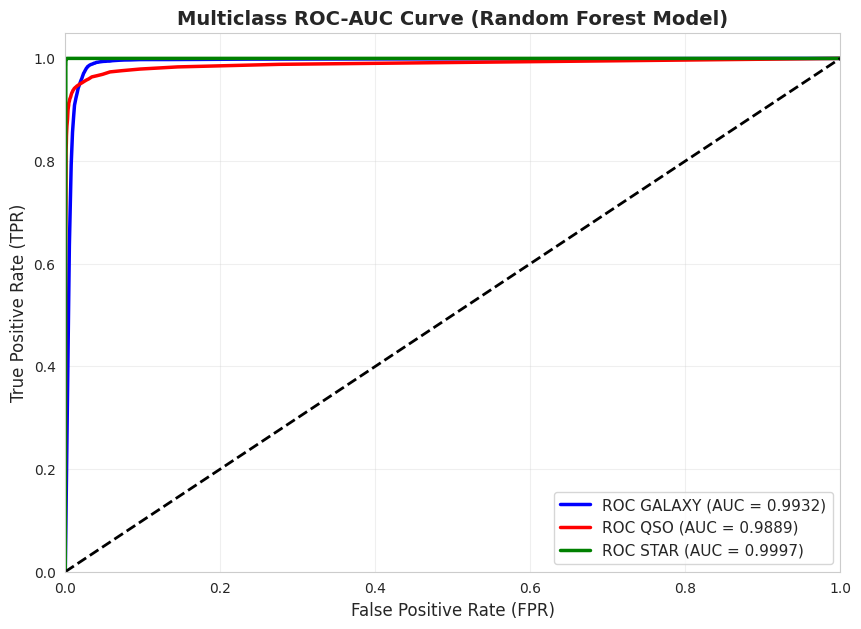

In [13]:
# Membinerkan label untuk kurva ROC (karena ada 3 kelas)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Mengambil probabilitas prediksi dari model terbaik (Random Forest)
rf_best = models['Random Forest']
y_score = rf_best.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()

# Menghitung False Positive Rate & True Positive Rate tiap kelas
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting Kurva ROC-AUC
plt.figure(figsize=(10, 7))
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Multiclass ROC-AUC Curve (Random Forest Model)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## SAVE MODEL

In [14]:
import joblib

# 1. Simpan Scaler (SANGAT PENTING karena SVM/LogReg sensitif skala)
joblib.dump(scaler, 'scaler_sdss.pkl')

# 2. Simpan Model dengan nama yang konsisten
# Sesuaikan variabel model dengan yang ada di loop training-mu
joblib.dump(models['Decision Tree'], 'model_dt.pkl')
joblib.dump(models['Random Forest'], 'model_rf.pkl')
joblib.dump(models['Logistic Regression'], 'model_logreg.pkl')

print("Semua model dan scaler berhasil disimpan!")

Semua model dan scaler berhasil disimpan!
